Math Dataset Shape: (395, 33)
Portuguese Dataset Shape: (649, 33)

Missing values in Math dataset: 0
Missing values in Portuguese dataset: 0
Duplicate rows in Math dataset: 0
Duplicate rows in Portuguese dataset: 0

Data Preprocessing complete: Binary variables successfully encoded.

--- MATH DATASET DESCRIPTIVE STATS ---
          count       mean       std   min   25%   50%   75%   max
age       395.0  16.696203  1.276043  15.0  16.0  17.0  18.0  22.0
absences  395.0   5.708861  8.003096   0.0   0.0   4.0   8.0  75.0
G1        395.0  10.908861  3.319195   3.0   8.0  11.0  13.0  19.0
G2        395.0  10.713924  3.761505   0.0   9.0  11.0  13.0  19.0
G3        395.0  10.415190  4.581443   0.0   8.0  11.0  14.0  20.0

--- PORTUGUESE DATASET DESCRIPTIVE STATS ---
          count       mean       std   min   25%   50%   75%   max
age       649.0  16.744222  1.218138  15.0  16.0  17.0  18.0  22.0
absences  649.0   3.659476  4.640759   0.0   0.0   2.0   6.0  32.0
G1        649.0  11.399076 

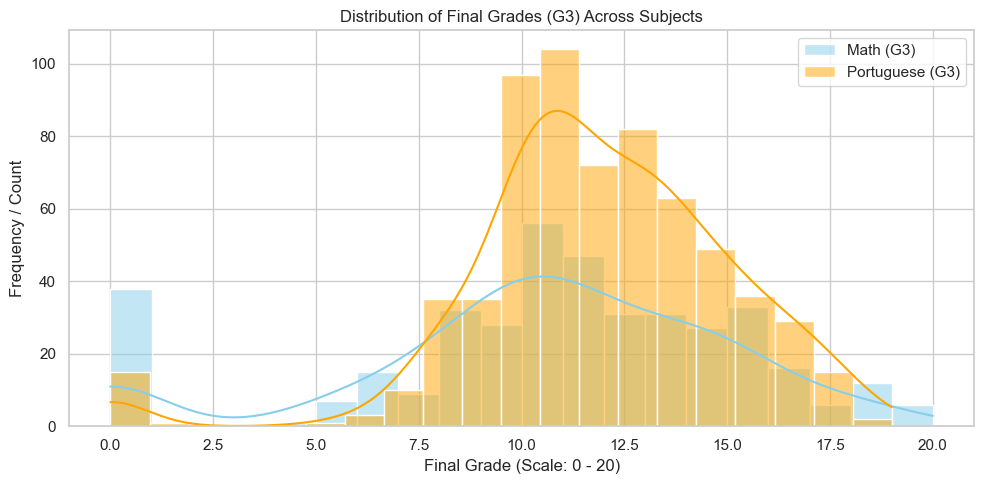

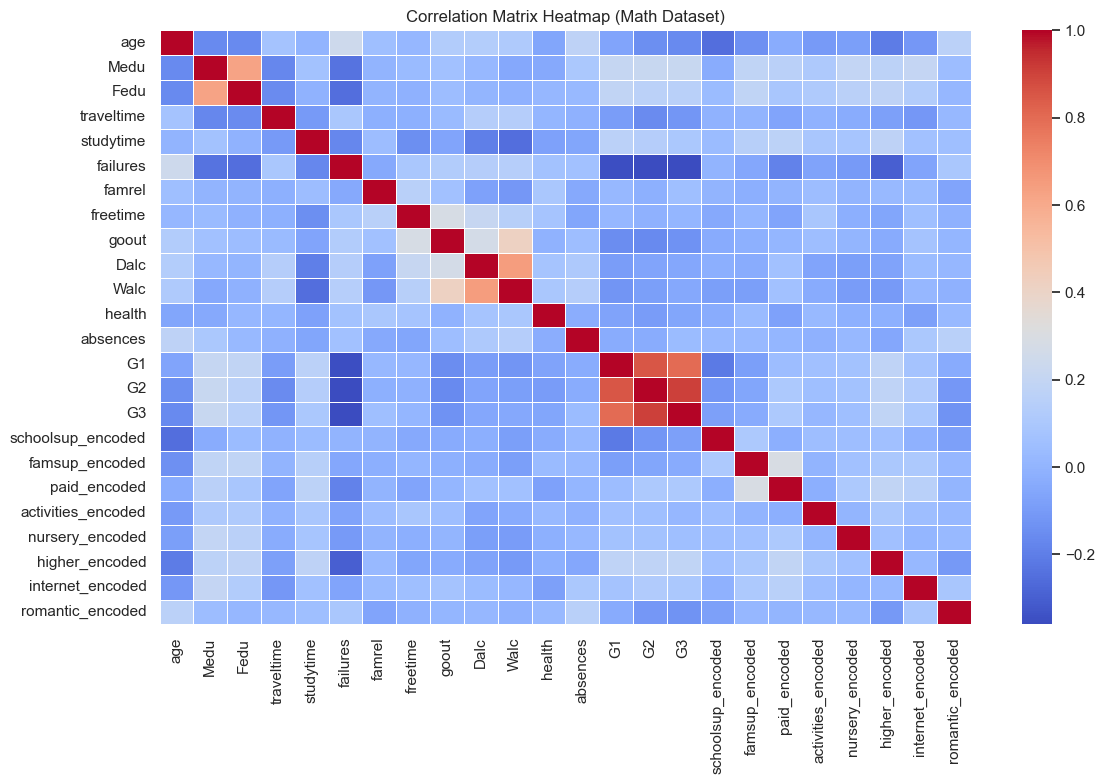

C:\Users\kartik\AppData\Local\Temp\ipykernel_31916\474465224.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="failures", y="G3", data=mat_df, palette="Set2")


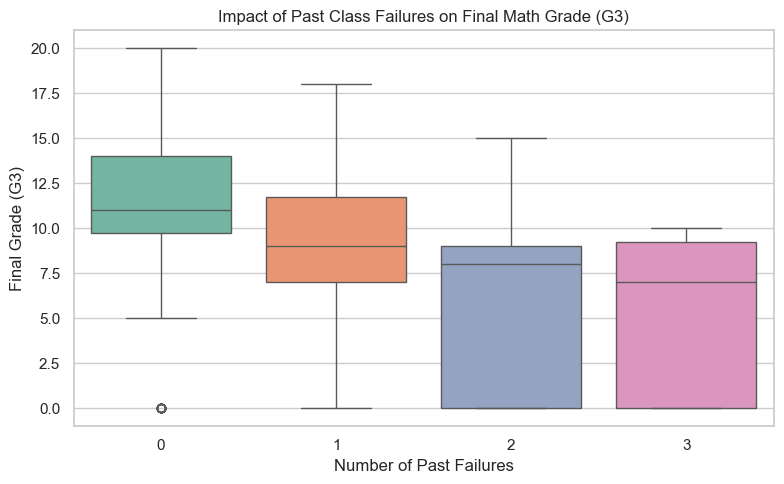

C:\Users\kartik\AppData\Local\Temp\ipykernel_31916\474465224.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="higher", y="G3", data=mat_df, palette="Pastel1")


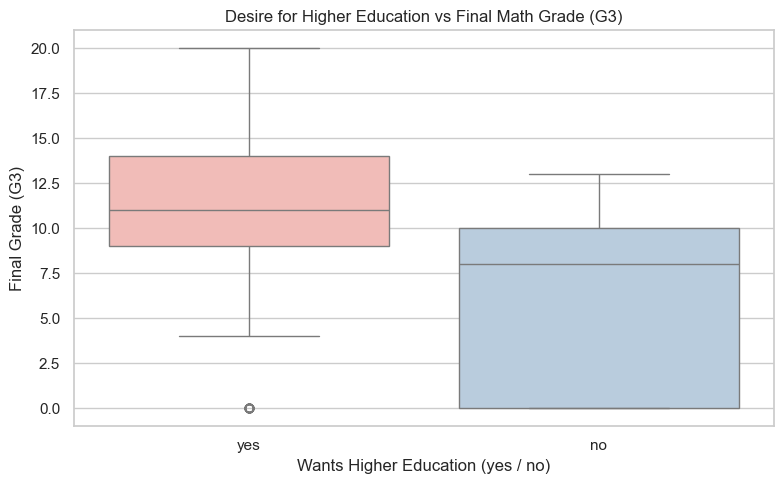

C:\Users\kartik\AppData\Local\Temp\ipykernel_31916\474465224.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Dalc", y="G3", data=por_df, palette="Blues_d", errorbar=None)


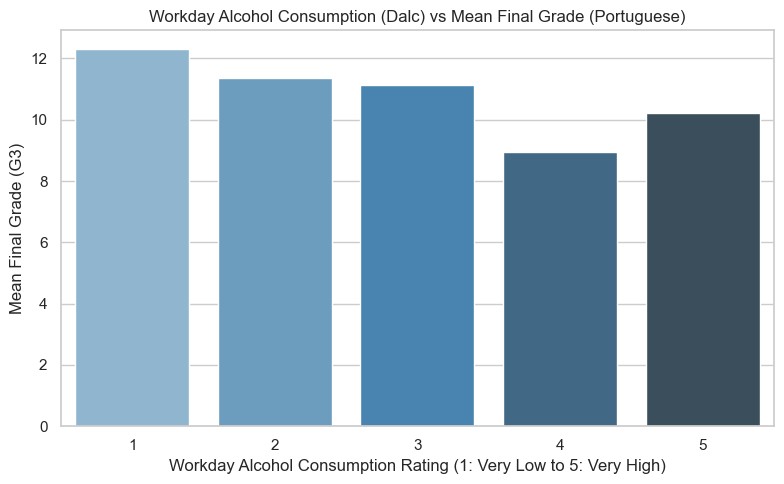


--- KEY DERIVED INSIGHTS ---
1. Final Grade Mean & Standard Deviation by Higher Education Ambition (Math):
        count    mean       std
higher                         
no         20   6.800  4.829732
yes       375  10.608  4.493422

2. Top 5 Features Correlated with Math Final Grade (G3):
G2                0.904868
G1                0.801468
Medu              0.217147
higher_encoded    0.182465
Fedu              0.152457
Name: G3, dtype: float64


In [3]:
# ==============================================================================
# STUDENT PERFORMANCE EXPLORATORY DATA ANALYSIS (EDA) SCRIPT
# ==============================================================================
# Objective: Explore student demographic, social, and academic factors 
# influencing final grades (G3) across Mathematics and Portuguese subjects.
# ==============================================================================

# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure default chart dimensions and visual theme for Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


# ==============================================================================
# STEP 1: DATA LOADING & PRELIMINARY INSPECTION
# ==============================================================================
# Attempt to load CSV files with standard comma delimiter; fallback to semicolon if needed
try:
    mat_df = pd.read_csv("student-mat.csv", sep=",")
    por_df = pd.read_csv("student-por.csv", sep=",")
except Exception:
    mat_df = pd.read_csv("student-mat.csv", sep=";")
    por_df = pd.read_csv("student-por.csv", sep=";")

# Display basic structural dimensions (rows, columns) of both datasets
print(f"Math Dataset Shape: {mat_df.shape}")
print(f"Portuguese Dataset Shape: {por_df.shape}")


# ==============================================================================
# STEP 2: DATA CLEANING & PREPROCESSING
# ==============================================================================
# Check total count of missing values across all columns
print(f"\nMissing values in Math dataset: {mat_df.isnull().sum().sum()}")
print(f"Missing values in Portuguese dataset: {por_df.isnull().sum().sum()}")

# Check for identical duplicate rows
print(f"Duplicate rows in Math dataset: {mat_df.duplicated().sum()}")
print(f"Duplicate rows in Portuguese dataset: {por_df.duplicated().sum()}")

# List of binary categorical columns requiring numerical transformation ('yes'/'no' -> 1/0)
binary_cols = [
    "schoolsup", "famsup", "paid", "activities", 
    "nursery", "higher", "internet", "romantic"
]

# Map binary string values ('yes', 'no') to integers (1, 0) for statistical modeling
for col in binary_cols:
    if col in mat_df.columns:
        mat_df[col + "_encoded"] = mat_df[col].map({"yes": 1, "no": 0})
    if col in por_df.columns:
        por_df[col + "_encoded"] = por_df[col].map({"yes": 1, "no": 0})

print("\nData Preprocessing complete: Binary variables successfully encoded.")


# ==============================================================================
# STEP 3: DESCRIPTIVE STATISTICS
# ==============================================================================
# Print summary statistics (mean, std, min, max, quartiles) for primary numerical metrics
print("\n--- MATH DATASET DESCRIPTIVE STATS ---")
print(mat_df[["age", "absences", "G1", "G2", "G3"]].describe().T)

print("\n--- PORTUGUESE DATASET DESCRIPTIVE STATS ---")
print(por_df[["age", "absences", "G1", "G2", "G3"]].describe().T)


# ==============================================================================
# STEP 4: EXPLORATORY DATA ANALYSIS (VISUALIZATIONS)
# ==============================================================================

# Chart 1: Compare Final Grade Distributions (G3) for Math vs Portuguese
plt.figure(figsize=(10, 5))
sns.histplot(mat_df["G3"], kde=True, color="skyblue", label="Math (G3)", bins=20)
sns.histplot(por_df["G3"], kde=True, color="orange", label="Portuguese (G3)", bins=20, alpha=0.5)
plt.title("Distribution of Final Grades (G3) Across Subjects")
plt.xlabel("Final Grade (Scale: 0 - 20)")
plt.ylabel("Frequency / Count")
plt.legend()
plt.tight_layout()
plt.show()

# Chart 2: Heatmap showing pairwise correlation between all numerical features in Math dataset
plt.figure(figsize=(12, 8))
numeric_mat = mat_df.select_dtypes(include=[np.number])
corr_mat = numeric_mat.corr()
sns.heatmap(corr_mat, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap (Math Dataset)")
plt.tight_layout()
plt.show()

# Chart 3: Boxplot demonstrating the impact of previous academic failures on final grade
plt.figure(figsize=(8, 5))
sns.boxplot(x="failures", y="G3", data=mat_df, palette="Set2")
plt.title("Impact of Past Class Failures on Final Math Grade (G3)")
plt.xlabel("Number of Past Failures")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

# Chart 4: Boxplot visualizing final grade differences based on higher education ambition
plt.figure(figsize=(8, 5))
sns.boxplot(x="higher", y="G3", data=mat_df, palette="Pastel1")
plt.title("Desire for Higher Education vs Final Math Grade (G3)")
plt.xlabel("Wants Higher Education (yes / no)")
plt.ylabel("Final Grade (G3)")
plt.tight_layout()
plt.show()

# Chart 5: Barplot evaluating the relationship between workday alcohol consumption and Portuguese grade
plt.figure(figsize=(8, 5))
sns.barplot(x="Dalc", y="G3", data=por_df, palette="Blues_d", errorbar=None)
plt.title("Workday Alcohol Consumption (Dalc) vs Mean Final Grade (Portuguese)")
plt.xlabel("Workday Alcohol Consumption Rating (1: Very Low to 5: Very High)")
plt.ylabel("Mean Final Grade (G3)")
plt.tight_layout()
plt.show()


# ==============================================================================
# STEP 5: KEY INSIGHTS OUTPUT
# ==============================================================================
# Print aggregated mathematical metrics to confirm visual observations
print("\n--- KEY DERIVED INSIGHTS ---")

# Insight 1: Quantify mean G3 difference based on higher education ambition
print("1. Final Grade Mean & Standard Deviation by Higher Education Ambition (Math):")
print(mat_df.groupby("higher")["G3"].agg(["count", "mean", "std"]))

# Insight 2: List variables with highest positive/negative correlation to final grade (G3)
print("\n2. Top 5 Features Correlated with Math Final Grade (G3):")
print(corr_mat["G3"].sort_values(ascending=False).drop("G3").head(5))